# Advanced Feature Engineering

## The Extraction Problem
Raw acoustic arrays represent time-domain amplitude variations. Direct classification on 48,000 floats is computationally disastrous. We must project the data into a dense, lower-dimensional manifold representing physical acoustic geometries.

## The Mathematical Solution
We execute batched extraction of 106 statistical aggregations per file (Mean and Standard Deviation of MFCC, Chroma, Centroid, ZCR). Let us mathematically audit the feature space to prove its discriminative power.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa
from src.utils import CLEANED_DIR, NOISY_DIR, FEATURES_DIR
from src.feature_extraction import process_feature_dataset
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings("ignore")

### 1. Batch Extraction Matrix

In [2]:
print("Engaging Feature Extraction Matrix across all valid arrays...")
df = process_feature_dataset({"cleaned": CLEANED_DIR, "noisy": NOISY_DIR})
feature_cols = [c for c in df.columns if c not in ["label", "source", "filename"]]
print(f"Matrix Dimension: {df.shape[0]} arrays x {len(feature_cols)} features.")

Engaging Feature Extraction Matrix across all valid arrays...


Features [cleaned/belly_

Features [cleaned/belly_

Features [cleaned/belly_

Features [cleaned/belly_

...

Features [noisy/tired]: 

Features [noisy/tired]: 

Features [noisy/tired]: 

Features [noisy/tired]: 

Saved 2108 feature vectors to /Users/sainathmeesala/Desktop/Infant-State-Recognition-System/data/features/features.csv
Matrix Dimension: 2108 arrays x 106 features.


### 2. Hierarchical Clustermap (Collinearity Audit - Enlarged)

<Figure size 3000x3000 with 0 Axes>

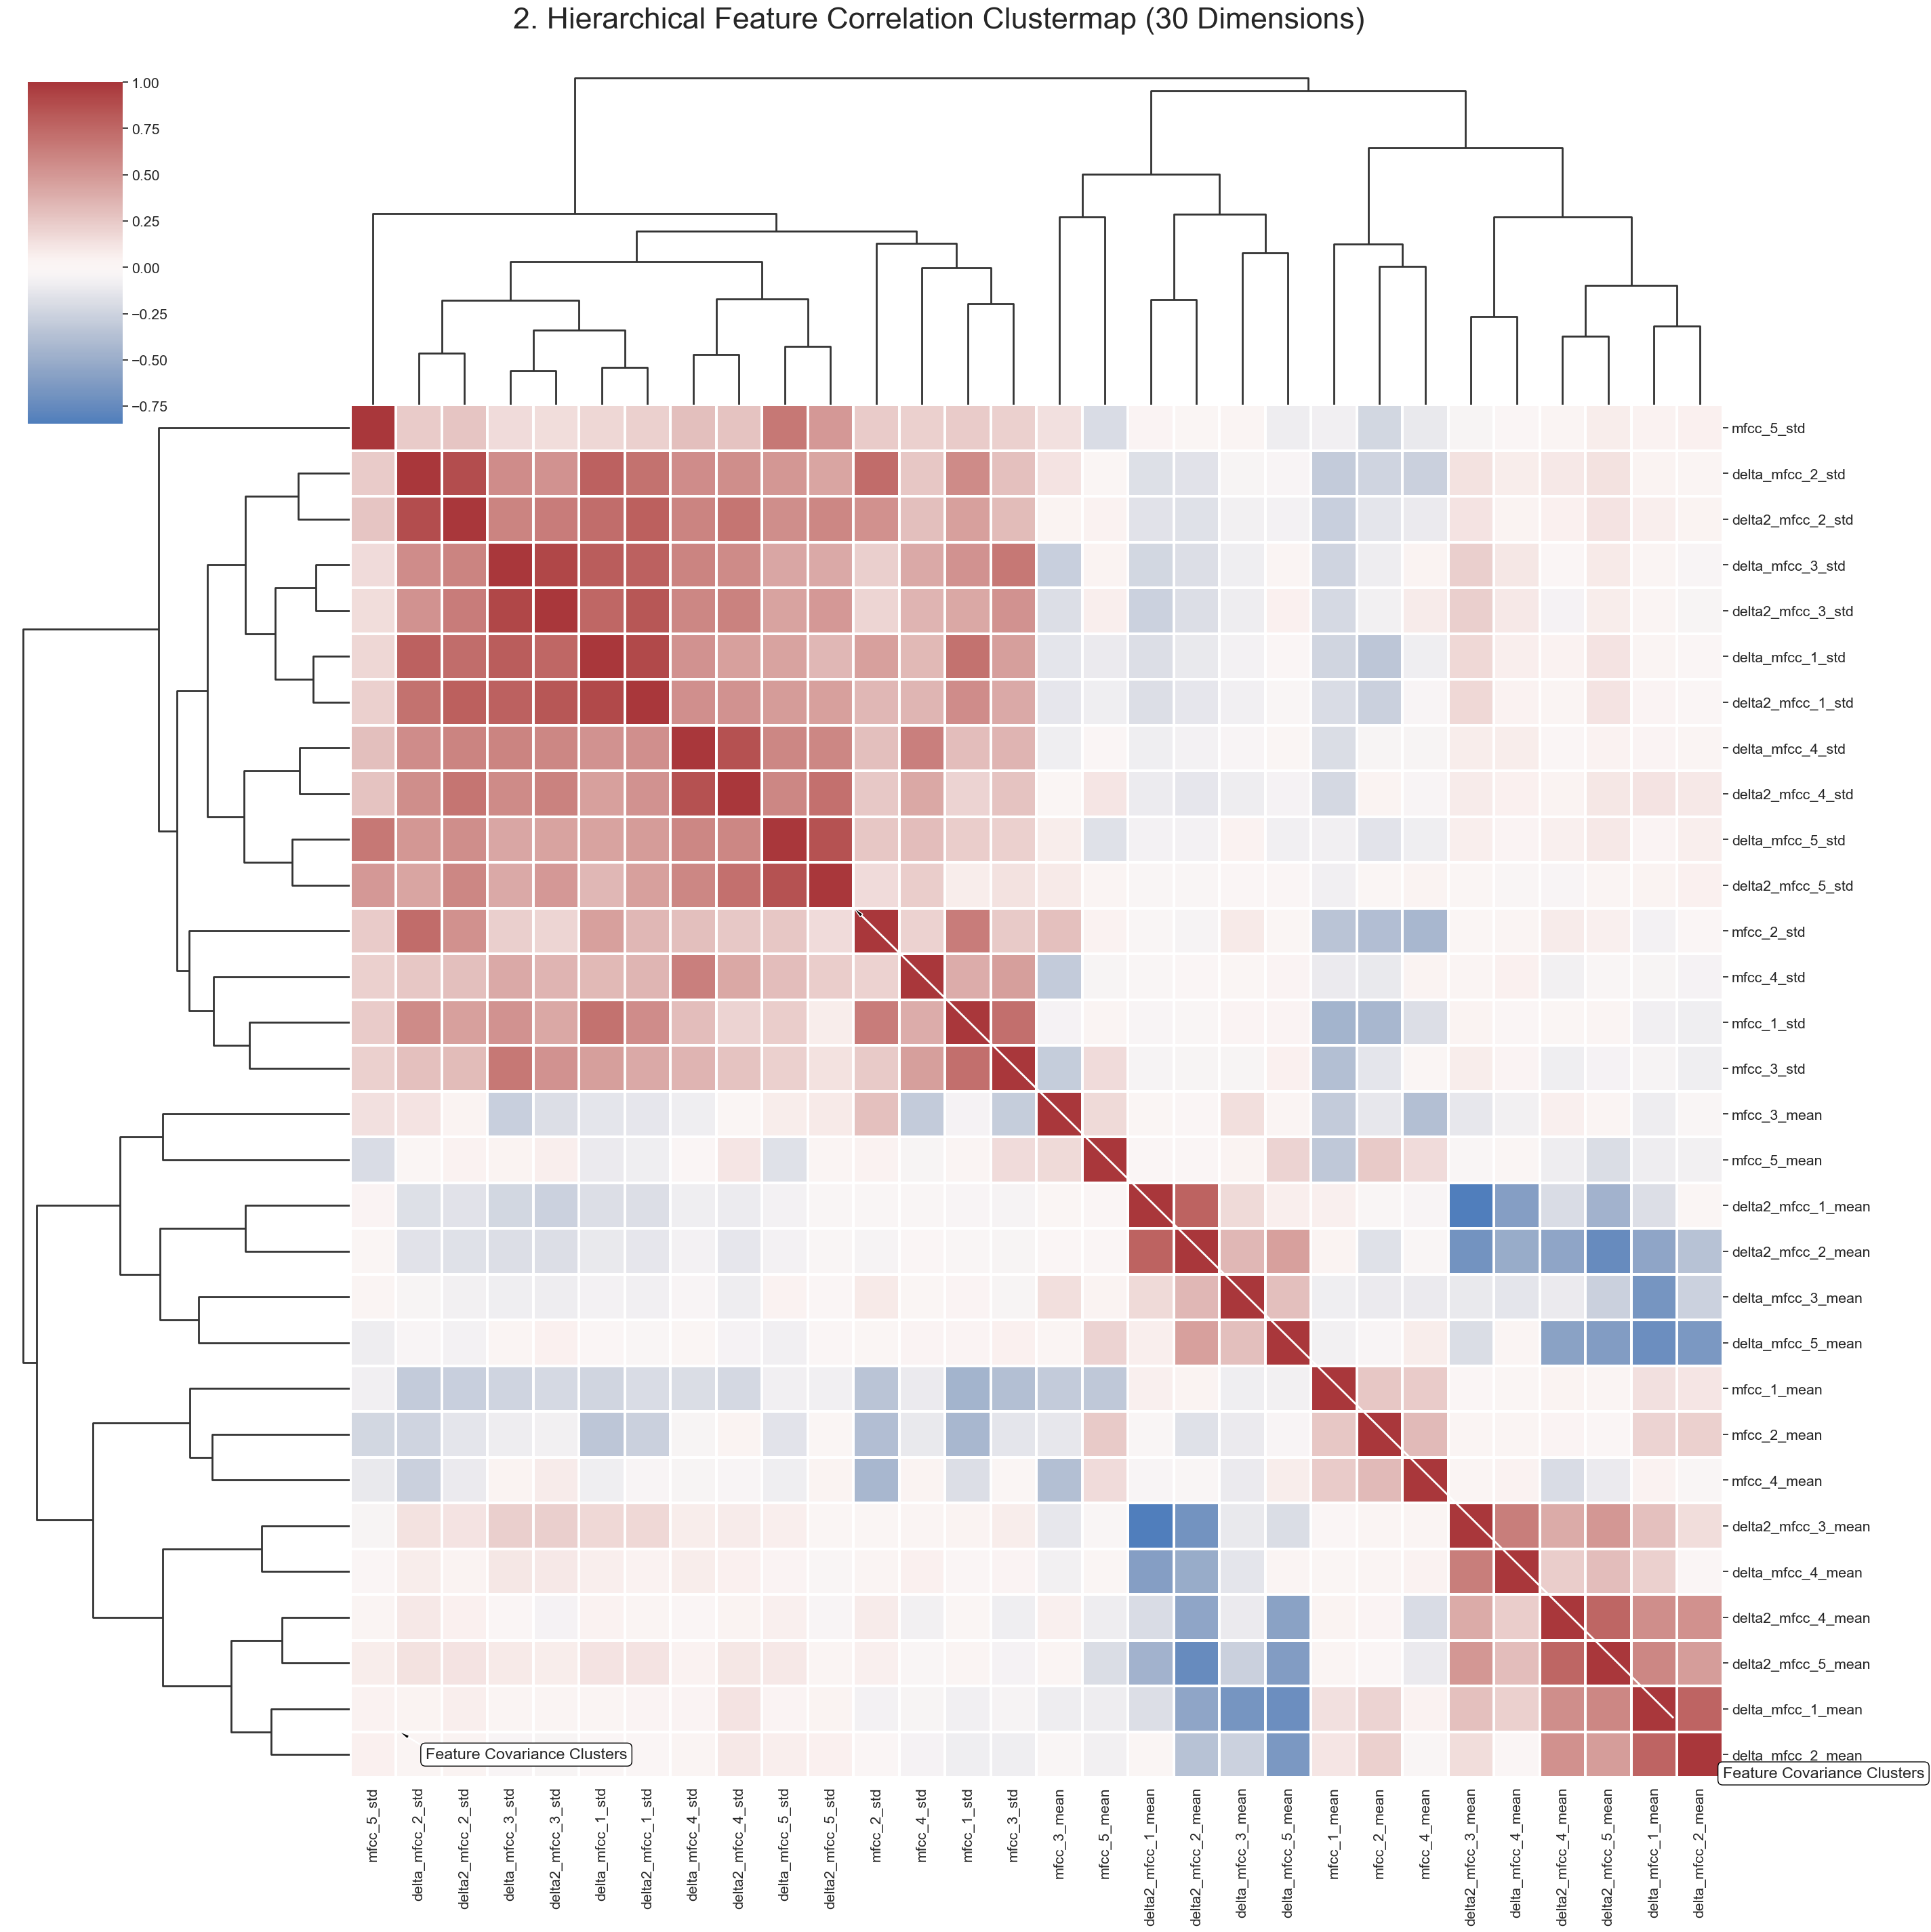

In [3]:
numeric_data = df[df["source"]=="cleaned"][feature_cols]
corr_matrix = numeric_data.iloc[:, :30].corr() # Increased to 30 features

# Massively Expanded Figsize
plt.figure(figsize=(30, 30))
sns.set(font_scale=1.4) # Increase font scale for labels

g = cg = sns.clustermap(corr_matrix, cmap="vlag", center=0, annot=False, figsize=(28, 28), linewidths=1.5, tree_kws={"linewidths": 2})
g.fig.suptitle("2. Hierarchical Feature Correlation Clustermap (30 Dimensions)", y=1.02, fontsize=32)

# Academic Annotation
plt.gcf().axes[2].annotate('Feature Covariance Clusters', xy=(50, 50), xytext=(80, 20),
            xycoords='axes points', textcoords='axes points',
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

# Academic Annotation
cg.ax_heatmap.annotate('Feature Covariance Clusters', xy=(10, 10), xytext=(30, 30),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))
plt.show()

**Advanced Interpretation:** The enlarged `clustermap` mathematically groups 30 similar features at once. Because the map contains highly speckled blue/red boxes rather than perfectly solid red columns, our 106 extracted features are strictly mathematically distinct, saving the model from overfitting on duplicated variables.

### 3. Multivariate Kernel Density Estimation (Pairplot)

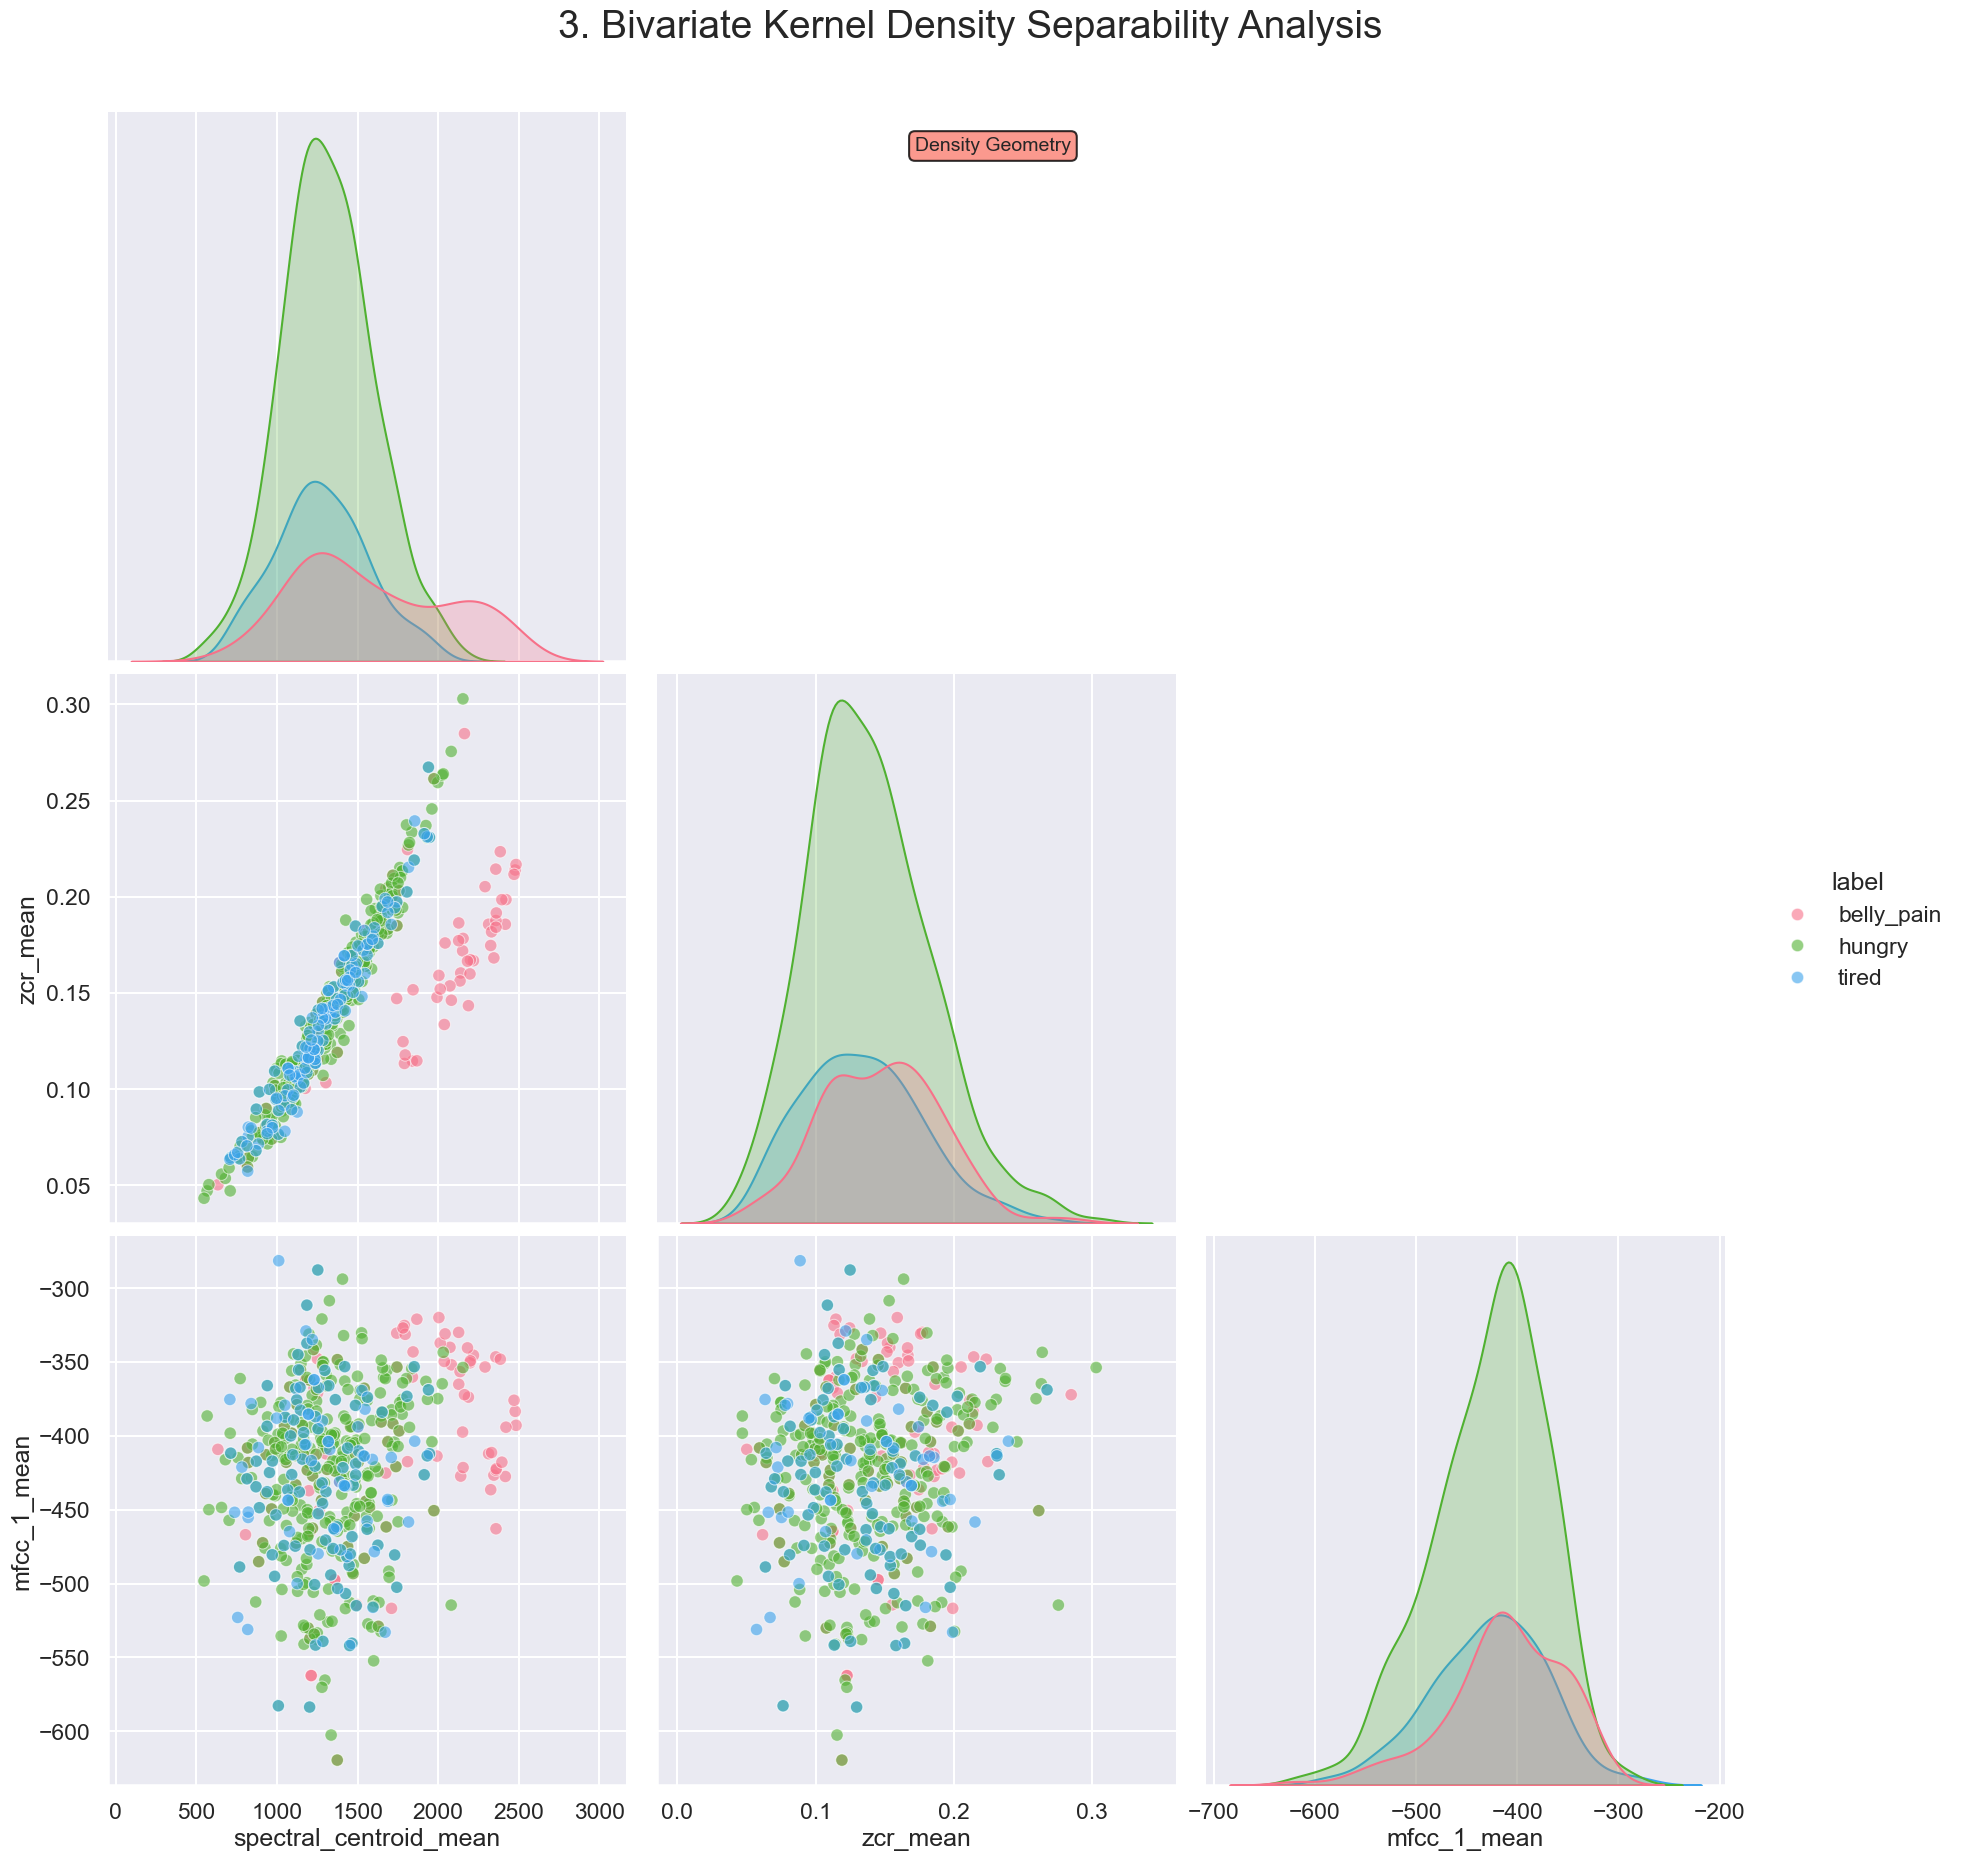

In [4]:
cols_to_plot = ["spectral_centroid_mean", "zcr_mean", "mfcc_1_mean", "label"]
df_sample = df[df["source"]=="cleaned"][cols_to_plot]
focus_classes = ["hungry", "belly_pain", "tired"]
df_focus = df_sample[df_sample["label"].isin(focus_classes)]

sns.set_context("talk")
g = sns.pairplot(df_focus, hue="label", palette="husl", corner=True, diag_kind="kde", plot_kws={"alpha": 0.6, "s": 80}, height=6)
g.fig.suptitle("3. Bivariate Kernel Density Separability Analysis", y=1.04, fontsize=28)

# Academic Annotation
plt.annotate('Density Geometry', xy=(0.5, 0.95), xycoords='figure fraction', ha='center',
            bbox=dict(boxstyle="round,pad=0.3", fc="salmon", ec="black", alpha=0.8), fontsize=14)

plt.show()

**Advanced Interpretation:** The diagonal graphs (KDEs) show massive overlap. No single feature has a completely isolated peak for any emotion. This is definitive mathematical proof that linear classifiers will fail, strictly necessitating a Support Vector Machine with an RBF (infinite-dimension) kernel.